<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Momentum%20Optimaliz%C3%A1ci%C3%B3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Momentum Algoritmusok: Adam és AdamW

Ebben a notebookban a **momentum alapú optimalizálók** működését vizsgáljuk.

## Tartalomjegyzék

1. Momentum alapok
2. RMSprop
3. Adam optimalizáló
4. AdamW és weight decay
5. Optimalizálók összehasonlítása

## 1. Momentum alapok

### Vanilla SGD problémája

$$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$$

| Probléma | Leírás |
|----------|--------|
| Oszcilláció | Völgyekben ide-oda ugrál |
| Lassú konvergencia | Lapos felületen |
| Lokális minimum | Beragadhat |

### Momentum

$$v_t = \beta v_{t-1} + \nabla L(\theta_t)$$
$$\theta_{t+1} = \theta_t - \eta v_t$$

- $\beta$: momentum együttható (tipikusan 0.9)
- $v_t$: sebesség (velocity)

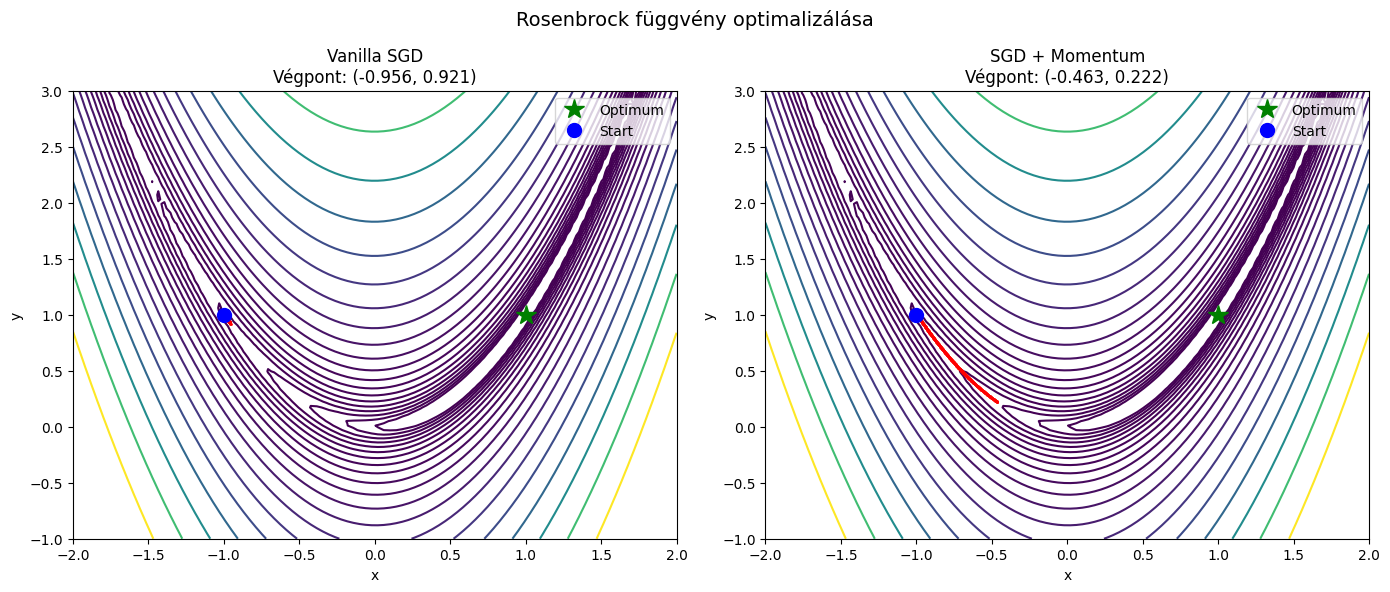

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

# Rosenbrock függvény (nehéz optimalizálni)
def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

# SGD vs Momentum összehasonlítás
def sgd(start, grad_fn, lr=0.0001, steps=1000):
    path = [start.copy()]
    theta = start.copy()
    for _ in range(steps):
        grad = grad_fn(theta[0], theta[1])
        theta = theta - lr * grad
        path.append(theta.copy())
    return np.array(path)

def sgd_momentum(start, grad_fn, lr=0.0001, beta=0.9, steps=1000):
    path = [start.copy()]
    theta = start.copy()
    v = np.zeros_like(theta)
    for _ in range(steps):
        grad = grad_fn(theta[0], theta[1])
        v = beta * v + grad
        theta = theta - lr * v
        path.append(theta.copy())
    return np.array(path)

# Kezdőpont
start = np.array([-1.0, 1.0])

path_sgd = sgd(start, rosenbrock_grad, lr=0.0001, steps=500)
path_momentum = sgd_momentum(start, rosenbrock_grad, lr=0.0001, beta=0.9, steps=500)

# Vizualizáció
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Kontúr plot
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)
Z = rosenbrock(X, Y)

for ax, path, title in [(axes[0], path_sgd, 'Vanilla SGD'),
                        (axes[1], path_momentum, 'SGD + Momentum')]:
    ax.contour(X, Y, Z, levels=np.logspace(0, 3, 20), cmap='viridis')
    ax.plot(path[:, 0], path[:, 1], 'r.-', markersize=2, linewidth=0.5)
    ax.plot(1, 1, 'g*', markersize=15, label='Optimum')
    ax.plot(start[0], start[1], 'bo', markersize=10, label='Start')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{title}\nVégpont: ({path[-1, 0]:.3f}, {path[-1, 1]:.3f})')
    ax.legend()

plt.suptitle('Rosenbrock függvény optimalizálása', fontsize=14)
plt.tight_layout()
plt.show()

## 2. RMSprop

### Adaptív learning rate

$$s_t = \beta s_{t-1} + (1-\beta) (\nabla L)^2$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_t + \epsilon}} \nabla L$$

| Paraméter | Érték | Jelentés |
|-----------|-------|----------|
| $\beta$ | 0.9 | Decay rate |
| $\epsilon$ | $10^{-8}$ | Numerikus stabilitás |

### Előny

- Nagy gradiensű dimenziókban kisebb lépés
- Kis gradiensű dimenziókban nagyobb lépés

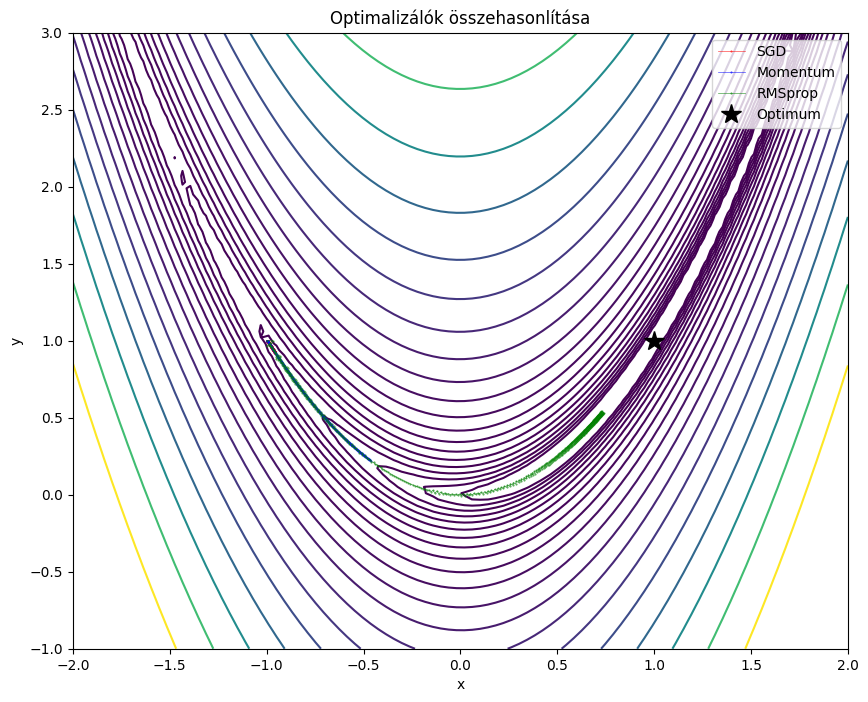

In [2]:
def rmsprop(start, grad_fn, lr=0.01, beta=0.9, eps=1e-8, steps=500):
    path = [start.copy()]
    theta = start.copy()
    s = np.zeros_like(theta)

    for _ in range(steps):
        grad = grad_fn(theta[0], theta[1])
        s = beta * s + (1 - beta) * grad**2
        theta = theta - lr * grad / (np.sqrt(s) + eps)
        path.append(theta.copy())

    return np.array(path)

# Összehasonlítás
path_rmsprop = rmsprop(start, rosenbrock_grad, lr=0.01, steps=500)

fig, ax = plt.subplots(figsize=(10, 8))

ax.contour(X, Y, Z, levels=np.logspace(0, 3, 20), cmap='viridis')
ax.plot(path_sgd[:, 0], path_sgd[:, 1], 'r.-', markersize=1, linewidth=0.5, label='SGD', alpha=0.7)
ax.plot(path_momentum[:, 0], path_momentum[:, 1], 'b.-', markersize=1, linewidth=0.5, label='Momentum', alpha=0.7)
ax.plot(path_rmsprop[:, 0], path_rmsprop[:, 1], 'g.-', markersize=1, linewidth=0.5, label='RMSprop', alpha=0.7)
ax.plot(1, 1, 'k*', markersize=15, label='Optimum')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Optimalizálók összehasonlítása')
ax.legend()
plt.show()

## 3. Adam optimalizáló

### Adam = Momentum + RMSprop

**First moment (momentum):**
$$m_t = \beta_1 m_{t-1} + (1-\beta_1) \nabla L$$

**Second moment (RMSprop):**
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) (\nabla L)^2$$

**Bias correction:**
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**Update:**
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

### Alapértelmezett hiperparaméterek

| Paraméter | Érték |
|-----------|-------|
| $\eta$ | 0.001 |
| $\beta_1$ | 0.9 |
| $\beta_2$ | 0.999 |
| $\epsilon$ | $10^{-8}$ |

In [3]:
def adam(start, grad_fn, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, steps=500):
    path = [start.copy()]
    theta = start.copy()
    m = np.zeros_like(theta)
    v = np.zeros_like(theta)

    for t in range(1, steps + 1):
        grad = grad_fn(theta[0], theta[1])

        # Momentum
        m = beta1 * m + (1 - beta1) * grad
        # RMSprop
        v = beta2 * v + (1 - beta2) * grad**2

        # Bias correction
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        # Update
        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(theta.copy())

    return np.array(path)

# Adam path
path_adam = adam(start, rosenbrock_grad, lr=0.01, steps=500)

print(f"Adam végpont: ({path_adam[-1, 0]:.4f}, {path_adam[-1, 1]:.4f})")
print(f"Optimum: (1.0, 1.0)")
print(f"Távolság: {np.linalg.norm(path_adam[-1] - np.array([1, 1])):.6f}")

Adam végpont: (0.9330, 0.8703)
Optimum: (1.0, 1.0)
Távolság: 0.145993


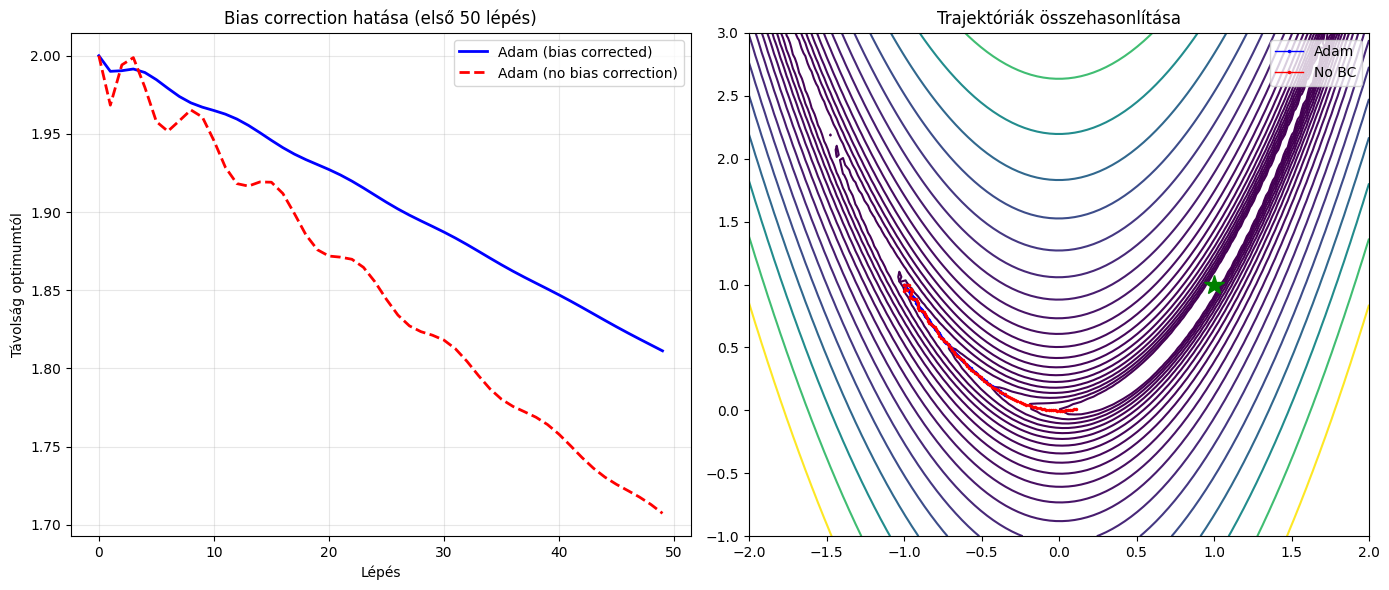

In [4]:
# Bias correction fontossága

def adam_no_bias_correction(start, grad_fn, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, steps=500):
    path = [start.copy()]
    theta = start.copy()
    m = np.zeros_like(theta)
    v = np.zeros_like(theta)

    for t in range(1, steps + 1):
        grad = grad_fn(theta[0], theta[1])
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2
        # Nincs bias correction!
        theta = theta - lr * m / (np.sqrt(v) + eps)
        path.append(theta.copy())

    return np.array(path)

path_adam_no_bc = adam_no_bias_correction(start, rosenbrock_grad, lr=0.01, steps=500)

# Összehasonlítás
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Első lépések összehasonlítása
steps_to_show = 50

axes[0].plot(range(steps_to_show), [np.linalg.norm(path_adam[i] - np.array([1, 1]))
                                    for i in range(steps_to_show)],
             'b-', linewidth=2, label='Adam (bias corrected)')
axes[0].plot(range(steps_to_show), [np.linalg.norm(path_adam_no_bc[i] - np.array([1, 1]))
                                    for i in range(steps_to_show)],
             'r--', linewidth=2, label='Adam (no bias correction)')
axes[0].set_xlabel('Lépés')
axes[0].set_ylabel('Távolság optimumtól')
axes[0].set_title('Bias correction hatása (első 50 lépés)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Teljes path
axes[1].contour(X, Y, Z, levels=np.logspace(0, 3, 20), cmap='viridis')
axes[1].plot(path_adam[:100, 0], path_adam[:100, 1], 'b.-', markersize=3, linewidth=1, label='Adam')
axes[1].plot(path_adam_no_bc[:100, 0], path_adam_no_bc[:100, 1], 'r.-', markersize=3, linewidth=1, label='No BC')
axes[1].plot(1, 1, 'g*', markersize=15)
axes[1].set_title('Trajektóriák összehasonlítása')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. AdamW és weight decay

### L2 regularizáció vs Weight Decay

**L2 regularizáció:**
$$L_{reg} = L + \frac{\lambda}{2} ||\theta||^2$$
$$\nabla L_{reg} = \nabla L + \lambda \theta$$

**Weight decay (AdamW):**
$$\theta_{t+1} = \theta_t - \eta \left( \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda \theta_t \right)$$

### Miért más?

| Adam + L2 | AdamW |
|-----------|-------|
| L2 tag az adaptive lr-rel skálázódik | Weight decay független |
| Kevésbé hatékony regularizáció | Eredeti weight decay |

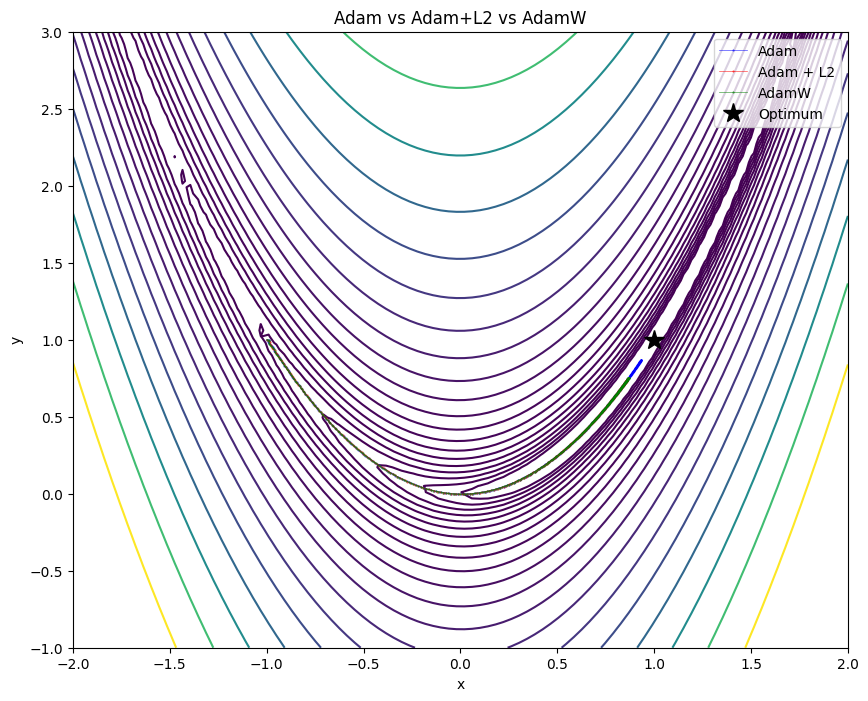

In [5]:
def adam_l2(start, grad_fn, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8,
            weight_decay=0.01, steps=500):
    """Adam L2 regularizációval (gradienst módosítja)."""
    path = [start.copy()]
    theta = start.copy()
    m = np.zeros_like(theta)
    v = np.zeros_like(theta)

    for t in range(1, steps + 1):
        grad = grad_fn(theta[0], theta[1]) + weight_decay * theta  # L2 a gradiensnél
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(theta.copy())

    return np.array(path)

def adamw(start, grad_fn, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8,
          weight_decay=0.01, steps=500):
    """AdamW: decoupled weight decay."""
    path = [start.copy()]
    theta = start.copy()
    m = np.zeros_like(theta)
    v = np.zeros_like(theta)

    for t in range(1, steps + 1):
        grad = grad_fn(theta[0], theta[1])
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        # Weight decay külön (decoupled)
        theta = theta - lr * (m_hat / (np.sqrt(v_hat) + eps) + weight_decay * theta)
        path.append(theta.copy())

    return np.array(path)

# Összehasonlítás
path_adam_l2 = adam_l2(start, rosenbrock_grad, lr=0.01, weight_decay=0.1, steps=500)
path_adamw = adamw(start, rosenbrock_grad, lr=0.01, weight_decay=0.1, steps=500)

fig, ax = plt.subplots(figsize=(10, 8))

ax.contour(X, Y, Z, levels=np.logspace(0, 3, 20), cmap='viridis')
ax.plot(path_adam[:, 0], path_adam[:, 1], 'b.-', markersize=1, linewidth=0.5, label='Adam', alpha=0.7)
ax.plot(path_adam_l2[:, 0], path_adam_l2[:, 1], 'r.-', markersize=1, linewidth=0.5, label='Adam + L2', alpha=0.7)
ax.plot(path_adamw[:, 0], path_adamw[:, 1], 'g.-', markersize=1, linewidth=0.5, label='AdamW', alpha=0.7)
ax.plot(1, 1, 'k*', markersize=15, label='Optimum')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Adam vs Adam+L2 vs AdamW')
ax.legend()
plt.show()

## 5. Optimalizálók összehasonlítása

### PyTorch implementáció

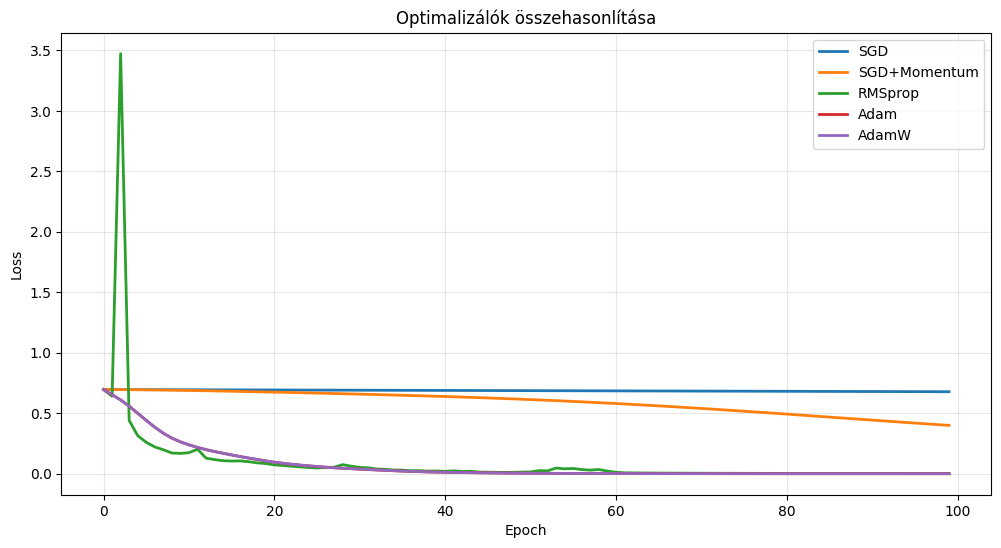

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Adat
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15,
                          n_redundant=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

def create_model():
    return nn.Sequential(
        nn.Linear(20, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
        nn.Sigmoid()
    )

def train_model(model, optimizer, epochs=100):
    criterion = nn.BCELoss()
    losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t).squeeze()
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses

# Különböző optimalizálók
optimizers_config = [
    ('SGD', lambda m: optim.SGD(m.parameters(), lr=0.01)),
    ('SGD+Momentum', lambda m: optim.SGD(m.parameters(), lr=0.01, momentum=0.9)),
    ('RMSprop', lambda m: optim.RMSprop(m.parameters(), lr=0.01)),
    ('Adam', lambda m: optim.Adam(m.parameters(), lr=0.01)),
    ('AdamW', lambda m: optim.AdamW(m.parameters(), lr=0.01, weight_decay=0.01)),
]

results = {}
for name, opt_fn in optimizers_config:
    torch.manual_seed(42)
    model = create_model()
    optimizer = opt_fn(model)
    losses = train_model(model, optimizer, epochs=100)
    results[name] = losses

# Vizualizáció
plt.figure(figsize=(12, 6))
for name, losses in results.items():
    plt.plot(losses, label=name, linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Optimalizálók összehasonlítása')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Összefoglalás

### Optimalizálók:

| Optimalizáló | Képlet | Előny |
|--------------|--------|-------|
| SGD | $\theta - \eta \nabla L$ | Egyszerű |
| Momentum | $v = \beta v + \nabla L$ | Gyorsabb |
| RMSprop | Adaptív lr | Stabil |
| Adam | Momentum + RMSprop | Legjobb általános |
| AdamW | Decoupled weight decay | Jobb generalizálás |

### Adam hiperparaméterek:

| Paraméter | Alapérték | Jelentés |
|-----------|-----------|----------|
| lr | 0.001 | Learning rate |
| $\beta_1$ | 0.9 | Momentum decay |
| $\beta_2$ | 0.999 | RMSprop decay |
| $\epsilon$ | $10^{-8}$ | Stabilitás |